# M5 Assignment 2
Feature Selection Using RFE and RFECV
Dataset Description
The Breast Cancer dataset is a binary classification dataset commonly used in machine learning for predictive modeling and evaluation. It contains measurements derived from digitized images of fine needle aspirate (FNA) of breast masses.

* Number of observations: 569
* Number of features: 30 numeric features
* Target variable: Diagnosis of breast cancer
    * 0 → Malignant
    * 1 → Benign

The features describe characteristics of the cell nuclei present in the image, such as radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry, and fractal dimension

Tasks
1. Import the dataset and identify predictor variables and the target variable
1. Split the data into training and testing sets
1. Train a baseline logistic regression model and report Accuracy and ROC–AUC.
1. Apply RFE to select 10 features and list the selected features.
1. Apply RFECV and report the optimal number of features selected.
1. Compare the performance of baseline, RFE, and RFECV models.

In [34]:
import pandas as pd

df = pd.read_csv("Breast Cancer.csv")
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [35]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [36]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [37]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

## Initial Understanding of the Variables

This dataset contains numerical measurements computed from digitized breast mass images. The objective is to predict whether a tumor is malignant or benign based on these measurements.

The predictor variables describe related physical properties of the cell nuclei, such as radius, perimeter, area, smoothness, compactness, concavity, symmetry, and fractal dimension. Since many of these measurements describe similar biological structures, some degree of correlation is expected.

In [38]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

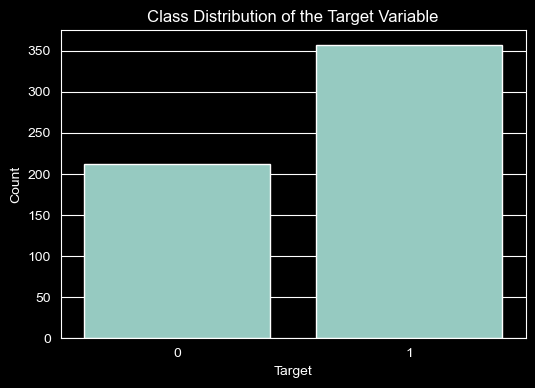

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Class Distribution of the Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

Reviewing the class distribution is important because severe imbalance may affect both model evaluation and feature selection. This check helps confirm whether the dataset is reasonably suitable for standard classification workflows.

In [40]:
X = df.drop(columns="target")
y = df["target"]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Predictor matrix shape: (569, 30)
Target vector shape: (569,)


The dataset contains many predictors, and several of them may be carrying overlapping information. That is why applying `RFE` and `RFECV` could be interesting.

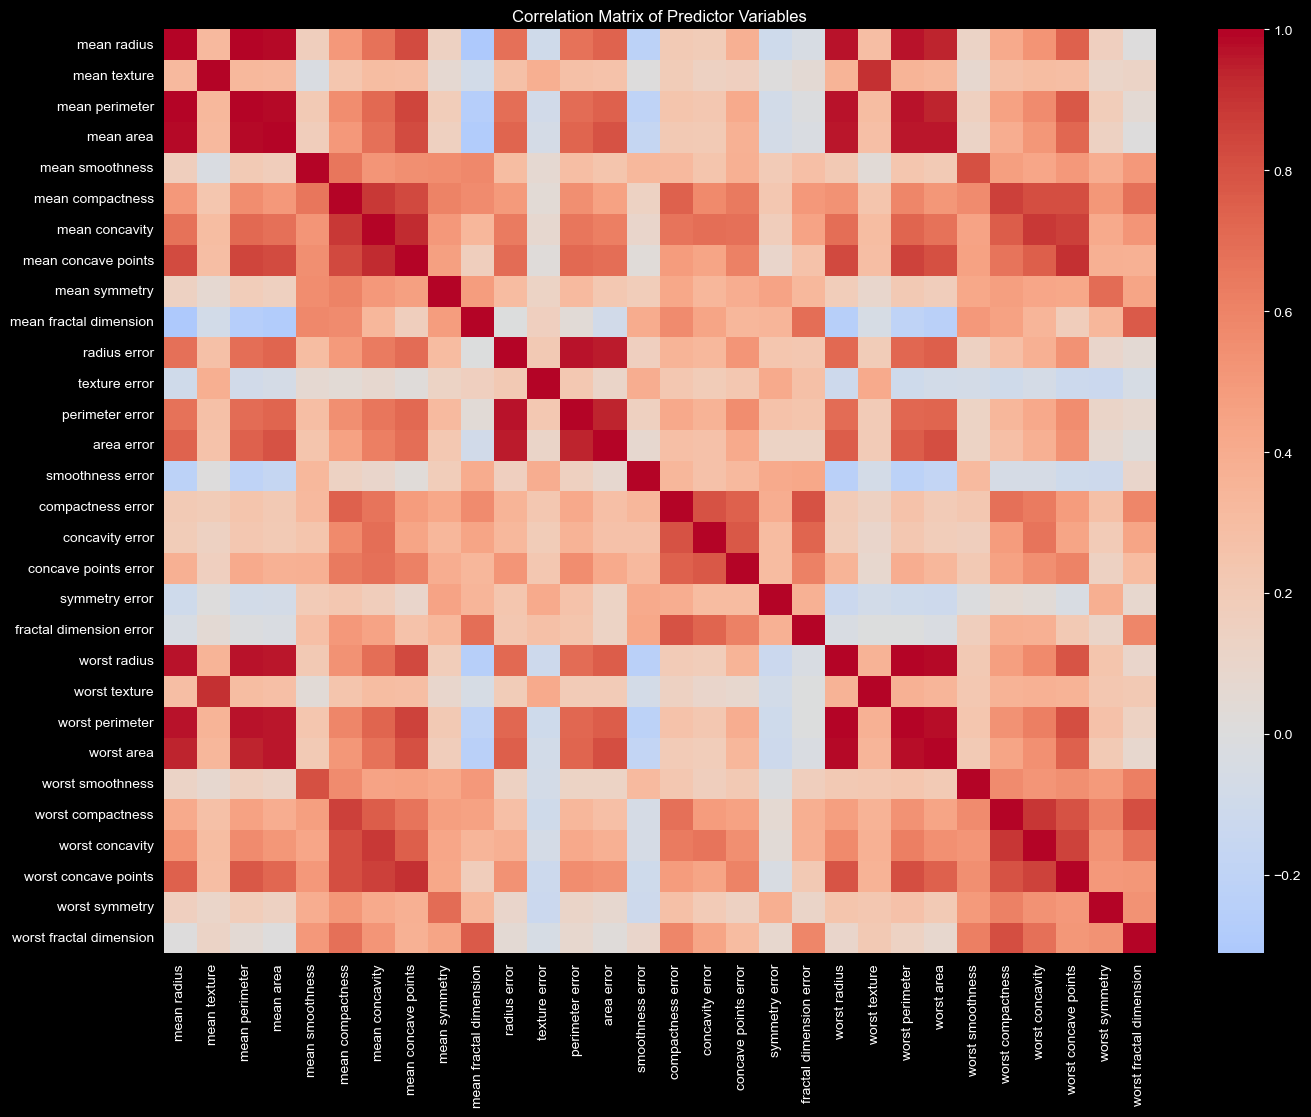

In [41]:
corr_matrix = X.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Predictor Variables")
plt.show()

The correlation heatmap helps identify groups of variables that carry similar information. In this dataset, several measurements are expected to be strongly related because they describe different aspects of the same tumor structure.

This provides an important motivation for feature selection: if multiple variables are highly correlated, it may be possible to keep a smaller subset of predictors without sacrificing much predictive power.

In [42]:
high_corr_pairs = corr_matrix.where(~corr_matrix.eq(1)).stack().reset_index()
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Feature_1"] < high_corr_pairs["Feature_2"]]
high_corr_pairs = high_corr_pairs.reindex(high_corr_pairs["Correlation"].abs().sort_values(ascending=False).index)

high_corr_pairs.head(15)

,Feature_1,Feature_2,Correlation
58,mean perimeter,mean radius,0.997855
658,worst perimeter,worst radius,0.993708
87,mean area,mean radius,0.987357
89,mean area,mean perimeter,0.986507
687,worst area,worst radius,0.984015
689,worst area,worst perimeter,0.977578
358,perimeter error,radius error,0.972794
79,mean perimeter,worst perimeter,0.970387
19,mean radius,worst radius,0.969539
77,mean perimeter,worst radius,0.969476


The strongest correlation pairs highlight where redundancy is most likely to occur. This supports the idea that recursive feature elimination can simplify the model by retaining the most informative variables while removing overlapping ones.

## Train-Test Split and Feature Scaling

Before applying feature selection, the data should be split into training and testing sets. This allows model performance to be evaluated on unseen observations.

Because logistic regression is sensitive to variable scale, the predictors will also be standardized.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (398, 30)
X_test shape: (171, 30)


The training set will be used for model fitting and feature selection, while the test set will be reserved for final performance comparison.

## Baseline Logistic Regression Model

A baseline logistic regression model is fitted using all available predictors. This provides a reference point for evaluating whether feature selection can simplify the model without sacrificing predictive performance.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_prob_baseline)

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline ROC-AUC:", round(baseline_roc_auc, 4))

Baseline Accuracy: 0.9883
Baseline ROC-AUC: 0.9981


These baseline results provide the benchmark for comparing the reduced models generated by `RFE` and `RFECV`.

## Recursive Feature Elimination (RFE)

RFE recursively removes the least important features and retains a predefined number of predictors. In this assignment, the procedure will select 10 features.

In [45]:
from sklearn.feature_selection import RFE

rfe_selector = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)
rfe_selector.fit(X_train_scaled, y_train)

selected_rfe_features = X.columns[rfe_selector.support_].tolist()
selected_rfe_features

['mean area',
 'mean concave points',
 'area error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst concave points',
 'worst symmetry']

The selected predictors represent the subset retained by the recursive elimination process.

In [46]:
X_train_rfe = X_train_scaled[:, rfe_selector.support_]
X_test_rfe = X_test_scaled[:, rfe_selector.support_]

rfe_model = LogisticRegression(max_iter=1000)
rfe_model.fit(X_train_rfe, y_train)

y_pred_rfe = rfe_model.predict(X_test_rfe)
y_prob_rfe = rfe_model.predict_proba(X_test_rfe)[:, 1]

rfe_accuracy = accuracy_score(y_test, y_pred_rfe)
rfe_roc_auc = roc_auc_score(y_test, y_prob_rfe)

print("RFE Accuracy:", round(rfe_accuracy, 4))
print("RFE ROC-AUC:", round(rfe_roc_auc, 4))

RFE Accuracy: 0.9708
RFE ROC-AUC: 0.9926


If the RFE model performs similarly to the baseline model, then the reduced feature set can be considered efficient and more interpretable.

## Recursive Feature Elimination with Cross-Validation (RFECV)

RFECV extends RFE by selecting the optimal number of features automatically through cross-validation.

In [47]:
from sklearn.feature_selection import RFECV

rfecv_selector = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=5,
    scoring="roc_auc"
)

rfecv_selector.fit(X_train_scaled, y_train)

optimal_rfecv_features = X.columns[rfecv_selector.support_].tolist()
print("Optimal number of features:", rfecv_selector.n_features_)
optimal_rfecv_features

Optimal number of features: 7


['area error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst concave points']

In [48]:
X_train_rfecv = X_train_scaled[:, rfecv_selector.support_]
X_test_rfecv = X_test_scaled[:, rfecv_selector.support_]

rfecv_model = LogisticRegression(max_iter=1000)
rfecv_model.fit(X_train_rfecv, y_train)

y_pred_rfecv = rfecv_model.predict(X_test_rfecv)
y_prob_rfecv = rfecv_model.predict_proba(X_test_rfecv)[:, 1]

rfecv_accuracy = accuracy_score(y_test, y_pred_rfecv)
rfecv_roc_auc = roc_auc_score(y_test, y_prob_rfecv)

print("RFECV Accuracy:", round(rfecv_accuracy, 4))
print("RFECV ROC-AUC:", round(rfecv_roc_auc, 4))

RFECV Accuracy: 0.9649
RFECV ROC-AUC: 0.9931


In [49]:
performance_comparison = pd.DataFrame({
    "Model": ["Baseline", "RFE", "RFECV"],
    "Accuracy": [baseline_accuracy, rfe_accuracy, rfecv_accuracy],
    "ROC_AUC": [baseline_roc_auc, rfe_roc_auc, rfecv_roc_auc],
    "Number_of_Features": [X.shape[1], len(selected_rfe_features), len(optimal_rfecv_features)]
})

performance_comparison.round(4)

,Model,Accuracy,ROC_AUC,Number_of_Features
0,Baseline,0.9883,0.9981,30
1,RFE,0.9708,0.9926,10
2,RFECV,0.9649,0.9931,7


The final comparison shows whether feature selection improved model efficiency. If `RFE` or `RFECV` achieves similar or better performance than the baseline with fewer predictors, then the reduced model is preferable because it is simpler and easier to interpret.